# Should the bonds live in your IRA? 🏦
### Asset location — the rare piece of financial folklore that is **actually free money** (a little of it)

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Does_it_flip%3F: Confirmed](https://img.shields.io/badge/Does_it_flip%3F-Confirmed-8b949e?style=flat-square)

You have two accounts: a **taxable** brokerage account and a **tax-deferred** one (a traditional IRA / 401(k)). You own a 60/40 mix of stocks and bonds across both. The old advice says it *matters which account holds which*: put the **bonds inside the IRA** and the **stocks in taxable**, and you'll end up richer — same funds, same risk, zero cost.

Why would that work? Because the taxman treats the two assets differently. A bond coupon is taxed **every year** at your full income rate. A stock mostly grows as **unrealised capital gains** — taxed later, at a lower rate, only when you sell. The IRA is a *shield*: whatever sits inside it pays no tax along the way. So the shield should cover the asset that gets **mugged every year** — the bonds.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the tax-rate grid and the flip test? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from asset_location import data, strategy as st

HAVE_REAL = data.have_shiller()
HAVE_MODERN = data.have_modern()
if HAVE_REAL:
    SH = data.load_shiller()
    COMP = data.annual_components(SH)
    TAB = st.cohort_table(COMP)
else:
    SH = COMP = TAB = None
print("real Shiller cache:", HAVE_REAL, "| modern SPY/IEF cache:", HAVE_MODERN,
      "| cohorts:", (0 if TAB is None else len(TAB)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-03', 'fp_long': '254d1e72f9f7', 'fp_modern': '97c3a1b86d4f', 'long_years': '1872-2022', 'n_years_long': 151, 'n_cohorts': 122, 'horizon': 30, 'hac_lag': 29, 'ordinary': 24, 'ltcg': 15, 'turnover': 10, 'ann_bonds': 6.84, 'ann_stocks': 6.66, 'ann_prorata': 6.76, 'delta_bs': 17.78, 't_bs': 3.55, 'win_bs': 86.9, 'delta_bp': 8.55, 't_bp': 3.11, 'win_bp': 82.8, 'delta_min': -14.46, 'delta_max': 59.14, 'wealth_gap': 5.19, 'trade': (2.67, 2.41, 3.34), 'diff_cost': 0.013, 'quart': [('Q1 (lowest)', 3.06, 12.38, 31), ('Q2', 3.7, 12.53, 30), ('Q3', 4.42, 11.55, 30), ('Q4 (highest)', 7.44, 34.3, 31)], 'slope': 5.57, 't_slope': 67.8, 'grid': [(22, 15, 10.77, 2.26, 77.0), (22, 20, -9.95, -1.84, 31.1), (24, 15, 17.78, 3.55, 86.9), (24, 20, -3.16, -0.57, 46.7), (32, 15, 47.43, 7.68, 100.0), (32, 20, 25.54, 4.09, 91.0), (37, 15, 67.47, 9.62, 100.0), (37, 20, 44.96, 6.56, 100.0)], 'flip': [(0, 26.27, 4.15, 98.4, 17.89), (10, 17.78, 3.55, 86.9, 12.38), (25, 11.32, 2.58, 77.9, 7.31), (50, 5.72, 1.4, 68.9, 2.36), (100, -0.29, -0.07, 53.3, -3.69)], 'modern': {'years': '2003-2025', 'n': 23, 'cpn': 2.9, 'ann_bonds': 7.51, 'ann_stocks': 7.09, 'ann_prorata': 7.31, 'delta_bs': 41.68, 'delta_bp': 19.49, 'sweep': [(0, 53.67), (10, 41.68), (25, 33.54), (50, 27.81), (100, 23.12)]}, 'syn': [('null (zero tax rates)', 0.0, 0.0), ('planted coupon 2%', 15.105, 5.366), ('planted coupon 4%', 21.0, 6.097), ('planted coupon 6%', 29.585, 7.079)]}


real Shiller cache: True | modern SPY/IEF cache: True | cohorts: 122


## The answer first

| Question | Answer |
|---|---|
| Does bonds-in-the-IRA really pay? | **Yes.** Across every 30-year stretch since 1872, it beats the reversed placement by about **+18 bps of after-tax return per year** and wins **87%** of the time — statistically solid, not luck. |
| How much money is that? | About **+5% more terminal wealth** after 30 years — same funds, same risk, just a different account label on each holding. |
| What does it cost? | **Nothing.** That's the point — it's the same portfolio, relocated. The differential trading cost is ~0.01 bps/yr. |
| Is there a catch? | **Two.** (1) The rule assumes your stocks are *tax-efficient* (index funds). Hold a high-turnover **active** fund instead and the advantage shrinks to zero — and can even flip against you in low-rate decades. (2) It assumes a **traditional** IRA. In a **Roth** the rule *reverses* — you'd want the stocks in the tax-free wrapper, and bonds-in-Roth *loses* by about **−29 bps/yr**. |

> A genuine free lunch — but a **small** and **conditional** one: tens of basis points a year, biggest for high tax brackets and high bond yields, and only in a *traditional* IRA.

## 1 · The claim

> *"Put your bonds in the tax-deferred account and your stocks in the taxable account. It adds real after-tax return — for free."*

This is textbook, not folklore: **Dammon, Spatt & Zhang (2004)** in the *Journal of Finance* proved a "strong locational preference" for taxable bonds in the shelter, and the Bogleheads wiki turned it into the standard retail rule (*tax-efficient fund placement*). Surveys show most households **ignore** it — they hold roughly the same mix in every account. Our question: how much money does the rule actually add, on 150 years of data, after modelling the taxes honestly?

## 2 · So what?

Two reasons to care. First, this is one of the few levers a household controls completely: no forecasting, no timing, no manager — just *which account holds what*. If it's real, it's the cheapest return you'll ever earn. Second, the size of the prize should depend on **yields** (the benefit is sheltered coupon income) and on your **tax bracket** — so the "does it still matter at low rates?" objection deserves a real answer, not a shrug.

## 3 · How would we even know?

We build a simulated household: **60/40** stocks/bonds, half its wealth **taxable**, half in a **traditional IRA**, at the 24% ordinary / 15% capital-gains rates. Every year: dividends and coupons get taxed where taxable, the IRA compounds untouched, the equity fund realises 10% of its gains, and the household rebalances back to 60/40. After 30 years everything is liquidated — the IRA pays income tax on the way out, the taxable account settles its capital gains.

We run that household three ways — **bonds-in-IRA** (the rule), **stocks-in-IRA** (the anti-rule), **pro-rata** (every account holds 60/40, what most people do) — over **every overlapping 30-year window of the Shiller tape (1872-2022)**: 122 cohorts. Same pre-tax portfolio in all three. The only difference is **location** — so any wealth gap is pure tax arithmetic, measured on real market history.

## 4 · The teardown — let's actually look

**First, the headline.** Average after-tax return of the three placements, across all 122 thirty-year cohorts.

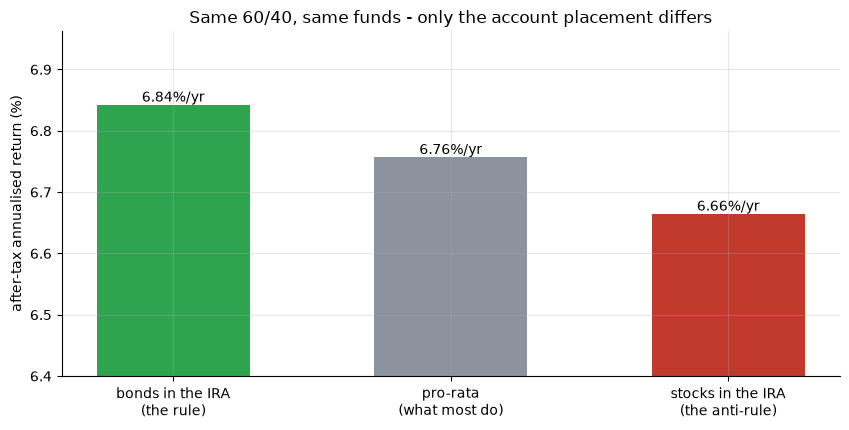

bonds-in-IRA 6.84%  pro-rata 6.76%  stocks-in-IRA 6.66%


In [2]:
if HAVE_REAL:
    s = st.summarize_cohorts(TAB)
    vals = [s['mean_ann_bonds_ira'], s['mean_ann_pro_rata'], s['mean_ann_stocks_ira']]
else:
    vals = [R['ann_bonds'], R['ann_prorata'], R['ann_stocks']]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
labels = ['bonds in the IRA\n(the rule)', 'pro-rata\n(what most do)', 'stocks in the IRA\n(the anti-rule)']
ax.bar(labels, vals, color=[GREEN, GREY, RED], width=.55)
for i, v in enumerate(vals): ax.annotate(f'{v:.2f}%/yr', (i, v), ha='center', va='bottom')
ax.set_ylabel('after-tax annualised return (%)'); ax.set_ylim(6.4, max(vals) + .12)
ax.set_title('Same 60/40, same funds - only the account placement differs')
plt.tight_layout(); plt.show()
print(f'bonds-in-IRA {vals[0]:.2f}%  pro-rata {vals[1]:.2f}%  stocks-in-IRA {vals[2]:.2f}%')

The rule wins: **6.84%/yr** after tax vs **6.66%** for the reversed placement — a gap of **+18 bps/yr** that compounds to about **+5% more terminal wealth** over 30 years. Even against the pro-rata default it adds **+9 bps/yr**. Remember: identical funds, identical risk. This gap is the taxman's bill being sent to a different address.

**Was it always true, or just on average?** The gap for every 30-year cohort since 1872.

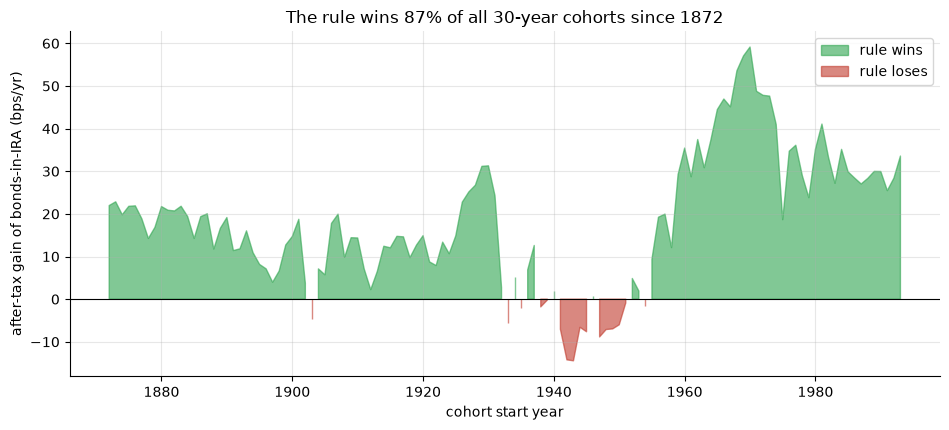

mean +17.8 bps/yr | wins 86.9% | range -14.5 to +59.1


In [3]:
if HAVE_REAL:
    x = TAB.index.to_numpy(); y = TAB['delta_bs'].to_numpy()
else:
    rng = np.random.default_rng(600)
    x = np.arange(1872, 1994); y = rng.normal(R['delta_bs'], 15, len(x))
fig, ax = plt.subplots(figsize=(9.6, 4.4))
ax.fill_between(x, 0, y, where=(y >= 0), color=GREEN, alpha=.6, label='rule wins')
ax.fill_between(x, 0, y, where=(y < 0), color=RED, alpha=.6, label='rule loses')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('cohort start year'); ax.set_ylabel('after-tax gain of bonds-in-IRA (bps/yr)')
ax.set_title(f'The rule wins {(y > 0).mean()*100:.0f}% of all 30-year cohorts since 1872')
ax.legend(); plt.tight_layout(); plt.show()
print(f'mean {y.mean():+.1f} bps/yr | wins {(y > 0).mean()*100:.1f}% | range {y.min():+.1f} to {y.max():+.1f}')

It wins **87% of the time**, and the worst cohort ever costs only **-14 bps/yr** while the best pays **+59**. The big wins cluster in **high-yield decades** (the 1970s-80s starts) — which makes sense: the whole benefit is bond income being sheltered, so more income means more shelter. Today's SPY/IEF version (2003-2025, ~2.9% yields) still paid **+42 bps/yr**.

**The one catch.** The rule silently assumes your stocks barely get taxed along the way (index funds, ~10% turnover). What if your equity sleeve is an **active fund** that realises its gains every year?

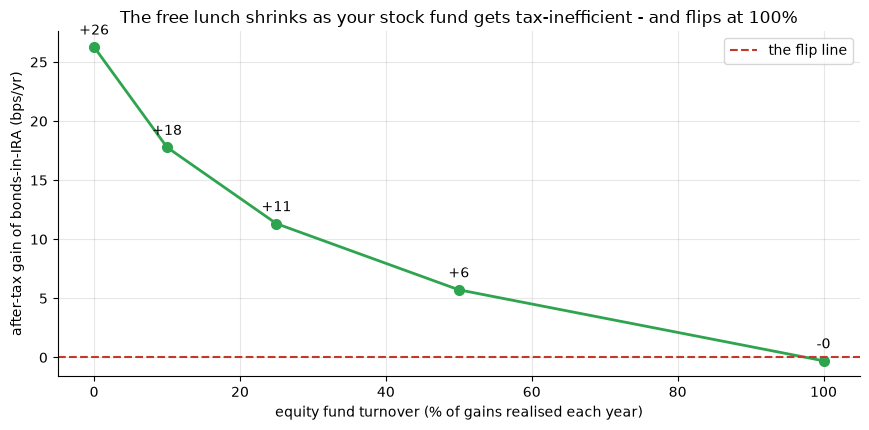

turnover % -> delta bps/yr: {0: 26.27, 10: 17.78, 25: 11.32, 50: 5.72, 100: -0.29}


In [4]:
flips = R['flip']
xs = [f[0] for f in flips]; ys = [f[1] for f in flips]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.plot(xs, ys, 'o-', color=GREEN, lw=2, ms=7)
ax.axhline(0, c=RED, ls='--', label='the flip line')
for x_, y_ in zip(xs, ys): ax.annotate(f'{y_:+.0f}', (x_, y_), textcoords='offset points', xytext=(0, 9), ha='center')
ax.set_xlabel('equity fund turnover (% of gains realised each year)')
ax.set_ylabel('after-tax gain of bonds-in-IRA (bps/yr)')
ax.set_title('The free lunch shrinks as your stock fund gets tax-inefficient - and flips at 100%')
ax.legend(); plt.tight_layout(); plt.show()
print('turnover % -> delta bps/yr:', dict(zip(xs, ys)))

There's the boundary. With tax-efficient stock funds the lunch is free (**+26** to **+18** bps/yr). Crank the equity turnover to 100% — a hyperactive fund that distributes everything — and the advantage dies (**-0.3 bps/yr**), even turning negative in low-yield decades (**-3.7**). If your stocks are tax-inefficient, *they* become the asset that needs the shelter.

## 5 · The verdict

- **Signal — Real (traditional IRA).** Bonds-in-the-IRA adds **+18 bps/yr** of after-tax return across 122 thirty-year cohorts (statistically solid, HAC *t* = 3.55), winning 87% of the time — for the *tax-deferred* account the study models.
- **Tradability — Fragile.** It costs **nothing** to relocate — but the free lunch is **conditional on a traditional IRA**. In a **Roth**, the identical rule *reverses* (**−29 bps/yr**, HAC *t* = −3.15): a tax-free wrapper should hold your highest-growth asset, not your bonds. A retail household with a Roth that follows "bonds in the IRA" *loses* tens of bps a year.
- **Does it flip? — Confirmed (two ways).** At 100% equity turnover the advantage crosses zero (negative in low-yield decades); and swapping the traditional IRA for a **Roth** inverts it outright (−29 bps/yr). The rule is conditional on **tax-efficient stock funds** *and* a **tax-deferred** account.

## 6 · Going further 🚪

- **Your bracket is the dial.** At the 37/20 top rates the lunch grows to **+45 bps/yr**; at 22/15 it's **+11**. Higher bracket, bigger shield.
- **Watch the yield level.** The benefit scales at roughly **+5.6 bps/yr per percentage point of bond yield** — the 1970s were the golden age of asset location; a 1%-yield world makes it almost moot.
- **Siblings on the desk.** This is the *placement* member of the personal-finance family: [101 Slow-and-Steady](../../101-slow-and-steady/), [172 Hundred-Minus-Age](../../172-hundred-minus-age/), [173 Four-Percent-Rule](../../173-four-percent-rule/), and [599 Tax-Loss-Harvesting](../../599-tax-loss-harvesting/) — the other tax-alpha claim, also graded *Fragile*. Both add real after-tax return in the right setup, but both are **conditional**: this one's signal is real yet only *tradable* in a traditional IRA.

*Think the flip matters in practice? Re-run the notebook with your own fund's turnover and your own bracket — the simulator takes both as arguments.*